In [1]:
%pip install tensorflow

  Using cached protobuf-7.35.1-cp310-abi3-win_amd64.whl.metadata (595 bytes)
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 2.1/351.2 MB 29.8 MB/s eta 0:00:12
    --------------------------------------- 7.3/351.2 MB 19.7 MB/s eta 0:00:18
   - -------------------------------------- 10.2/351.2 MB 17.5 MB/s eta 0:00:20
   - -------------------------------------- 14.7/351.2 MB 21.6 MB/s eta 0:00:16
   - -------------------------------------- 16.8/351.2 MB 19.6 MB/s eta 0:00:18
   -- ------------------------------------- 24.9/351.2 MB 20.6 MB/s eta 0:00:16
   --- ------------------------------------ 26.7/351.2 MB 19.0 MB/s eta 0:00:18
   --- ------------------------------------ 33.3/351.2 MB 20.5 MB/s eta 0:00:16
   ---- ----------------------------------- 35.7/351.2 MB 21.4 MB/s eta 0:00:15
   ---- ----------------------------------- 40.9/351.2 MB 20.1 MB/s eta 0:00:16
   ----- ---------------------------------- 45.9/351.2

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.51.0 requires protobuf<7,>=3.20, but you have protobuf 7.35.1 which is incompatible.


In [2]:
%pip install "protobuf>=5.28.0,<7" --upgrade

  Attempting uninstall: protobuf
    Found existing installation: protobuf 7.35.1
    Uninstalling protobuf-7.35.1:
      Successfully uninstalled protobuf-7.35.1
Note: you may need to restart the kernel to use updated packages.


In [1]:
import streamlit
import google.protobuf
import tensorflow as tf

print("Streamlit:", streamlit.__version__)
print("Protobuf:", google.protobuf.__version__)
print("TensorFlow:", tf.__version__)

Streamlit: 1.51.0
Protobuf: 6.33.6
TensorFlow: 2.21.0


In [2]:
%pip check

No broken requirements found.
Note: you may need to restart the kernel to use updated packages.


In [1]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("TensorFlow working successfully!")

TensorFlow version: 2.21.0
TensorFlow working successfully!


In [2]:
import os
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout
)
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

print("Random seed set successfully!")

Random seed set successfully!


In [4]:
train_data = pd.read_csv(
    "train_fraud_balanced.csv"
)

validation_data = pd.read_csv(
    "validation_fraud.csv"
)

print("Training dataset:", train_data.shape)
print("Validation dataset:", validation_data.shape)

Training dataset: (79328, 45)
Validation dataset: (8648, 45)


In [5]:
if "is_fraud" not in train_data.columns:
    raise ValueError(
        "is_fraud column is missing from training data."
    )

if "is_fraud" not in validation_data.columns:
    raise ValueError(
        "is_fraud column is missing from validation data."
    )

print("Target column found successfully!")

Target column found successfully!


In [6]:
X_train = train_data.drop(
    columns=["is_fraud"]
)

y_train = train_data["is_fraud"]

X_validation = validation_data.drop(
    columns=["is_fraud"]
)

y_validation = validation_data["is_fraud"]

In [7]:
common_columns = [
    column for column in X_train.columns
    if column in X_validation.columns
]

if len(common_columns) == 0:
    raise ValueError(
        "No common feature columns were found."
    )

X_train = X_train[common_columns].copy()
X_validation = X_validation[common_columns].copy()

print("Common features:", len(common_columns))

Common features: 44


In [8]:
for column in common_columns:

    X_train[column] = pd.to_numeric(
        X_train[column],
        errors="coerce"
    )

    X_validation[column] = pd.to_numeric(
        X_validation[column],
        errors="coerce"
    )

print("Features converted to numeric.")

Features converted to numeric.


In [9]:
usable_columns = [
    column for column in X_train.columns
    if X_train[column].notna().any()
]

if len(usable_columns) == 0:
    raise ValueError(
        "No usable numeric features were found."
    )

X_train = X_train[usable_columns].copy()
X_validation = X_validation[usable_columns].copy()

print("Usable features:", len(usable_columns))
print(usable_columns)

Usable features: 22
['amount', 'is_international', 'is_card_present', 'transactions_last_24h', 'average_amount_30d', 'risk_score', 'transaction_hour', 'transaction_day', 'transaction_month', 'sender_balance_before', 'sender_balance_after', 'receiver_balance_before', 'receiver_balance_after', 'login_attempts', 'account_age_days', 'email_age_days', 'failed_payment_attempts', 'customer_balance', 'distance_from_home_km', 'transactions_last_1h', 'new_device', 'new_location']


In [10]:
y_train = pd.to_numeric(
    y_train,
    errors="coerce"
)

y_validation = pd.to_numeric(
    y_validation,
    errors="coerce"
)

valid_train_rows = y_train.notna()
valid_validation_rows = y_validation.notna()

X_train = X_train.loc[
    valid_train_rows
].reset_index(drop=True)

y_train = y_train.loc[
    valid_train_rows
].astype(int).reset_index(drop=True)

X_validation = X_validation.loc[
    valid_validation_rows
].reset_index(drop=True)

y_validation = y_validation.loc[
    valid_validation_rows
].astype(int).reset_index(drop=True)

print("Training classes:")
print(y_train.value_counts())

print("\nValidation classes:")
print(y_validation.value_counts())

Training classes:
is_fraud
0    39664
1    39664
Name: count, dtype: int64

Validation classes:
is_fraud
0    8499
1     149
Name: count, dtype: int64


In [11]:
training_medians = X_train.median()

X_train = X_train.fillna(
    training_medians
)

X_validation = X_validation.fillna(
    training_medians
)

X_train = X_train.fillna(0)
X_validation = X_validation.fillna(0)

print(
    "Training missing values:",
    X_train.isnull().sum().sum()
)

print(
    "Validation missing values:",
    X_validation.isnull().sum().sum()
)

Training missing values: 0
Validation missing values: 0


In [12]:
X_train_normal = X_train[
    y_train == 0
].copy()

if X_train_normal.empty:
    raise ValueError(
        "No normal training transactions were found."
    )

print(
    "Normal transactions used for training:",
    X_train_normal.shape
)

Normal transactions used for training: (39664, 22)


In [13]:
scaler = StandardScaler()

X_train_normal_scaled = scaler.fit_transform(
    X_train_normal
)

X_validation_scaled = scaler.transform(
    X_validation
)

X_train_normal_scaled = X_train_normal_scaled.astype(
    "float32"
)

X_validation_scaled = X_validation_scaled.astype(
    "float32"
)

print("Feature scaling completed!")

Feature scaling completed!


In [14]:
number_of_features = X_train_normal_scaled.shape[1]

encoding_size = max(
    2,
    number_of_features // 2
)

input_layer = Input(
    shape=(number_of_features,)
)

encoded = Dense(
    encoding_size,
    activation="relu"
)(input_layer)

encoded = Dropout(
    0.1
)(encoded)

bottleneck = Dense(
    max(2, encoding_size // 2),
    activation="relu"
)(encoded)

decoded = Dense(
    encoding_size,
    activation="relu"
)(bottleneck)

output_layer = Dense(
    number_of_features,
    activation="linear"
)(decoded)

autoencoder_model = Model(
    inputs=input_layer,
    outputs=output_layer
)

print("Autoencoder created successfully!")

Autoencoder created successfully!


In [15]:
autoencoder_model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

autoencoder_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 22)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 11)                  │             253 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 11)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 5)                   │              60 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 11)                  │              66 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 22)                  │             264 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 643 (2.51 KB)

 Trainable params: 643 (2.51 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [17]:
training_history = autoencoder_model.fit(
    X_train_normal_scaled,
    X_train_normal_scaled,
    epochs=50,
    batch_size=128,
    validation_split=0.20,
    callbacks=[early_stopping],
    shuffle=True,
    verbose=1
)

print("Autoencoder trained successfully!")

Epoch 1/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.9765 - val_loss: 0.8357
Epoch 2/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8374 - val_loss: 0.7283
Epoch 3/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.7567 - val_loss: 0.6576
Epoch 4/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7017 - val_loss: 0.6083
Epoch 5/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6696 - val_loss: 0.5878
Epoch 6/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6560 - val_loss: 0.5745
Epoch 7/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6480 - val_loss: 0.5650
Epoch 8/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6374 - val_loss: 0.5573
Epoch 9/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6309 - val_loss: 0.5514
Epoch 10/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6254 - val_loss: 0.5459
Epoch 11/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6188 - val_loss: 0.5401
Epoch 12/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

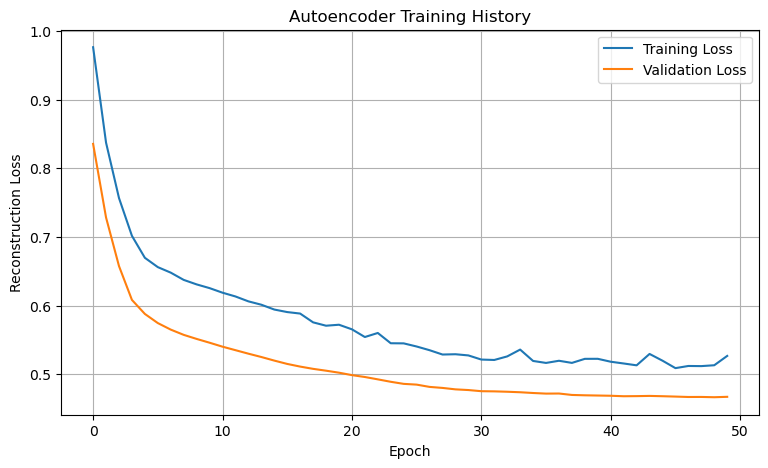

In [18]:
plt.figure(figsize=(9, 5))

plt.plot(
    training_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    training_history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Autoencoder Training History")
plt.xlabel("Epoch")
plt.ylabel("Reconstruction Loss")
plt.legend()
plt.grid(True)
plt.show()

In [19]:
validation_reconstructed = autoencoder_model.predict(
    X_validation_scaled,
    verbose=0
)

print("Validation transactions reconstructed!")

Validation transactions reconstructed!


In [20]:
validation_reconstruction_error = np.mean(
    np.square(
        X_validation_scaled -
        validation_reconstructed
    ),
    axis=1
)

print(
    "Average reconstruction error:",
    round(
        float(
            validation_reconstruction_error.mean()
        ),
        4
    )
)

Average reconstruction error: 0.4791


In [21]:
precision_values, recall_values, thresholds = (
    precision_recall_curve(
        y_validation,
        validation_reconstruction_error
    )
)

f1_values = (
    2 *
    precision_values[:-1] *
    recall_values[:-1]
) / (
    precision_values[:-1] +
    recall_values[:-1] +
    1e-10
)

if len(thresholds) == 0:
    raise ValueError(
        "A threshold could not be calculated."
    )

best_threshold_index = np.argmax(
    f1_values
)

best_threshold = thresholds[
    best_threshold_index
]

print(
    "Best reconstruction threshold:",
    round(float(best_threshold), 4)
)

print(
    "Best validation F1:",
    round(
        float(f1_values[best_threshold_index]),
        4
    )
)

Best reconstruction threshold: 0.4975
Best validation F1: 0.0445


In [22]:
autoencoder_predictions = (
    validation_reconstruction_error >=
    best_threshold
).astype(int)

print("Autoencoder predictions created!")

Autoencoder predictions created!


In [23]:
autoencoder_accuracy = accuracy_score(
    y_validation,
    autoencoder_predictions
)

autoencoder_precision = precision_score(
    y_validation,
    autoencoder_predictions,
    zero_division=0
)

autoencoder_recall = recall_score(
    y_validation,
    autoencoder_predictions,
    zero_division=0
)

autoencoder_f1 = f1_score(
    y_validation,
    autoencoder_predictions,
    zero_division=0
)

autoencoder_roc_auc = roc_auc_score(
    y_validation,
    validation_reconstruction_error
)

print("AUTOENCODER ANOMALY RESULTS")
print("---------------------------")
print("Accuracy:", round(autoencoder_accuracy, 4))
print("Precision:", round(autoencoder_precision, 4))
print("Recall:", round(autoencoder_recall, 4))
print("F1 Score:", round(autoencoder_f1, 4))
print("ROC-AUC:", round(autoencoder_roc_auc, 4))

AUTOENCODER ANOMALY RESULTS
---------------------------
Accuracy: 0.707
Precision: 0.0236
Recall: 0.396
F1 Score: 0.0445
ROC-AUC: 0.5524


In [24]:
print(
    classification_report(
        y_validation,
        autoencoder_predictions,
        labels=[0, 1],
        target_names=["Normal", "Fraud"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

      Normal       0.99      0.71      0.83      8499
       Fraud       0.02      0.40      0.04       149

    accuracy                           0.71      8648
   macro avg       0.50      0.55      0.44      8648
weighted avg       0.97      0.71      0.81      8648



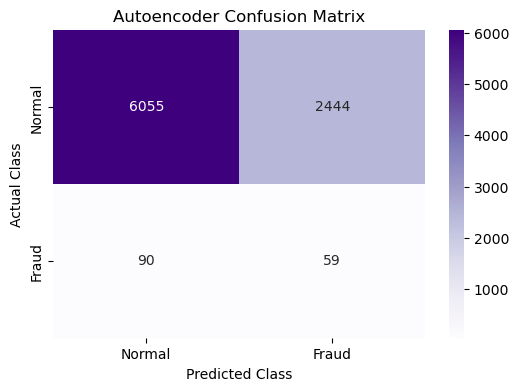

In [25]:
autoencoder_confusion = confusion_matrix(
    y_validation,
    autoencoder_predictions,
    labels=[0, 1]
)

plt.figure(figsize=(6, 4))

sns.heatmap(
    autoencoder_confusion,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=["Normal", "Fraud"],
    yticklabels=["Normal", "Fraud"]
)

plt.title("Autoencoder Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

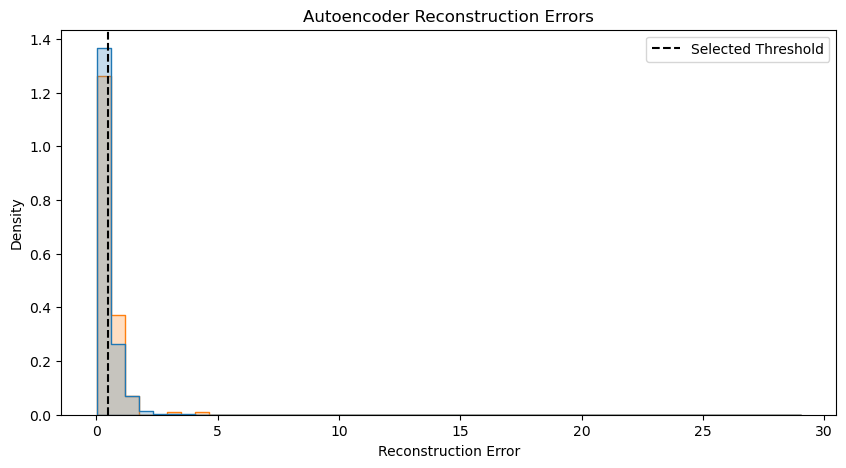

In [26]:
error_data = pd.DataFrame({
    "reconstruction_error":
        validation_reconstruction_error,

    "actual_class": y_validation.map({
        0: "Normal",
        1: "Fraud"
    })
})

plt.figure(figsize=(10, 5))

sns.histplot(
    data=error_data,
    x="reconstruction_error",
    hue="actual_class",
    bins=50,
    element="step",
    stat="density",
    common_norm=False
)

plt.axvline(
    best_threshold,
    color="black",
    linestyle="--",
    label="Selected Threshold"
)

plt.title("Autoencoder Reconstruction Errors")
plt.xlabel("Reconstruction Error")
plt.ylabel("Density")
plt.legend()
plt.show()

In [27]:
autoencoder_results = pd.DataFrame({
    "model": ["Autoencoder"],
    "accuracy": [autoencoder_accuracy],
    "precision": [autoencoder_precision],
    "recall": [autoencoder_recall],
    "f1_score": [autoencoder_f1],
    "roc_auc": [autoencoder_roc_auc],
    "threshold": [best_threshold]
})

autoencoder_results.round(4)

,model,accuracy,precision,recall,f1_score,roc_auc,threshold
0,Autoencoder,0.707,0.0236,0.396,0.0445,0.5524,0.4975


In [28]:
autoencoder_validation_results = pd.DataFrame({
    "actual_fraud": y_validation,
    "predicted_fraud": autoencoder_predictions,
    "reconstruction_error":
        validation_reconstruction_error
})

autoencoder_validation_results.to_csv(
    "autoencoder_fraud_predictions.csv",
    index=False
)

print("Predictions saved successfully!")

Predictions saved successfully!


In [29]:
autoencoder_results.to_csv(
    "autoencoder_fraud_results.csv",
    index=False
)

print("Autoencoder results saved successfully!")

Autoencoder results saved successfully!


In [30]:
autoencoder_model.save(
    "autoencoder_fraud_model.keras"
)

print("Autoencoder model saved successfully!")

Autoencoder model saved successfully!


In [31]:
comparison_file = (
    "model_comparison_with_isolation_forest.csv"
)

comparison_columns = [
    "model",
    "accuracy",
    "precision",
    "recall",
    "f1_score",
    "roc_auc"
]

if os.path.exists(comparison_file):

    previous_results = pd.read_csv(
        comparison_file
    )

    previous_results.columns = (
        previous_results.columns
        .str.strip()
        .str.lower()
    )

    final_comparison = pd.concat(
        [
            previous_results[comparison_columns],
            autoencoder_results[
                comparison_columns
            ]
        ],
        ignore_index=True
    )

else:

    final_comparison = autoencoder_results[
        comparison_columns
    ].copy()

final_comparison = final_comparison.drop_duplicates(
    subset=["model"],
    keep="last"
)

final_comparison.round(4)

,model,accuracy,precision,recall,f1_score,roc_auc
0,Optimized XGBoost,0.9085,0.0603,0.2953,0.1001,0.6272
1,Random Forest,0.8784,0.0552,0.3758,0.0962,0.6506
2,Decision Tree,0.8484,0.0468,0.4027,0.0839,0.6140
3,XGBoost,0.8392,0.0407,0.3691,0.0733,0.6465
4,Logistic Regression Baseline,0.6895,0.0314,0.5705,0.0595,0.6556
5,SVM,0.6950,0.0313,0.5570,0.0592,0.6550
6,Isolation Forest,0.2298,0.0189,0.8591,0.0370,0.5031
7,Autoencoder,0.7070,0.0236,0.3960,0.0445,0.5524


In [32]:
final_comparison.to_csv(
    "model_comparison_with_autoencoder.csv",
    index=False
)

print("Updated model comparison saved!")

Updated model comparison saved!
